In [1]:
import pandas as pd
from scipy.stats import fisher_exact
import numpy as np
from scipy.stats import wilcoxon


In [2]:
def get_motif_wise_densities(fimo_tsv, fasta_file, num_motifs):
    # 1. 加载 FIMO 结果
    df = pd.read_csv(fimo_tsv, sep='\t', skipfooter=3, engine='python')
    
    # 2. 计算总序列长度 (kb)
    from Bio import SeqIO
    total_kb = sum(len(record.seq) for record in SeqIO.parse(fasta_file, "fasta")) / 1000
    
    # 3. 统计每个单独 Motif 的总 Hits
    motif_counts = df.groupby('motif_id').size()
    
    # 4. 计算每个 Motif 的密度: Hits / Total_kb
    # 即使某些 Motif 没被搜到，也要补 0
    densities = (motif_counts / total_kb).to_dict()
    
    return densities

In [5]:

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from Bio import SeqIO

def get_motif_sequence_fraction(fimo_tsv, fasta_file):
    # 1. 统计 FASTA 文件中的总序列条数
    total_seqs = sum(1 for _ in SeqIO.parse(fasta_file, "fasta"))
    
    # 2. 加载 FIMO 结果
    df = pd.read_csv(fimo_tsv, sep='\t', skipfooter=3, engine='python')
    
    # 3. 统计每个 Motif 命中了多少条【不重复的序列】
    # FIMO 结果中序列名称通常列名为 'sequence_name'
    unique_hits = df.groupby('motif_id')['sequence_name'].nunique()
    
    # 4. 计算占比: 包含该 Motif 的序列数 / 总序列数
    fractions = (unique_hits / total_seqs).to_dict()
    
    return fractions

# ==========================================
# 获取 EV-motifs 在两组序列中的序列命中占比
# ==========================================
ev_motifs_on_cyto = get_motif_sequence_fraction("/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/enrichment/fimo_EV_motif_on_Cyto_seq/fimo.tsv", "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/circRNA_ligated/Cyto_sequences.fasta")
ev_motifs_on_ev = get_motif_sequence_fraction("/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/enrichment/fimo_EV_motif_on_EV_seq/fimo.tsv", "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/circRNA_ligated/EV_sequences.fasta")

# 确保两个字典的 Key 一致，进行配对
all_ev_motif_ids = set(ev_motifs_on_ev.keys()) | set(ev_motifs_on_cyto.keys())
pair_ev_EVseq = [ev_motifs_on_ev.get(m, 0) for m in all_ev_motif_ids]
pair_ev_Cytoseq = [ev_motifs_on_cyto.get(m, 0) for m in all_ev_motif_ids]

# 进行配对检验（检验 EV-motifs 在 EV 序列中的命中比例是否显著高于在 Cyto 序列中的比例）
stat_ev, pval_ev = wilcoxon(pair_ev_EVseq, pair_ev_Cytoseq, alternative='greater')

print("=== EV Motifs 富集分析 (序列比例) ===")
print(f"在 EV 序列中平均有 {np.mean(pair_ev_EVseq)*100:.2f}% 的序列包含这些 Motif")
print(f"在 Cyto 序列中平均有 {np.mean(pair_ev_Cytoseq)*100:.2f}% 的序列包含这些 Motif")
print(f"配对检验 P-value: {pval_ev:.4e}\n")


# ==========================================
# 获取 Cyto-motifs 在两组序列中的序列命中占比
# ==========================================
cyto_motifs_on_cyto = get_motif_sequence_fraction("/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/enrichment/fimo_Cyto_motif_on_Cyto_seq/fimo.tsv", "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/circRNA_ligated/Cyto_sequences.fasta")
cyto_motifs_on_ev = get_motif_sequence_fraction("/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/enrichment/fimo_Cyto_motif_on_EV_seq/fimo.tsv", "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/circRNA_ligated/EV_sequences.fasta")

all_cyto_motif_ids = set(cyto_motifs_on_cyto.keys()) | set(cyto_motifs_on_ev.keys())
pair_cyto_Cytoseq = [cyto_motifs_on_cyto.get(m, 0) for m in all_cyto_motif_ids]
pair_cyto_EVseq = [cyto_motifs_on_ev.get(m, 0) for m in all_cyto_motif_ids]

# 进行配对检验（检验 Cyto-motifs 在 Cyto 序列中的命中比例是否显著高于在 EV 序列中的比例）
stat_cyto, pval_cyto = wilcoxon(pair_cyto_Cytoseq, pair_cyto_EVseq, alternative='greater')

print("=== Cyto Motifs 富集分析 (序列比例) ===")
print(f"在 Cyto 序列中平均有 {np.mean(pair_cyto_Cytoseq)*100:.2f}% 的序列包含这些 Motif")
print(f"在 EV 序列中平均有 {np.mean(pair_cyto_EVseq)*100:.2f}% 的序列包含这些 Motif")
print(f"配对检验 P-value: {pval_cyto:.4e}")


=== EV Motifs 富集分析 (序列比例) ===
在 EV 序列中平均有 6.68% 的序列包含这些 Motif
在 Cyto 序列中平均有 7.81% 的序列包含这些 Motif
配对检验 P-value: 9.8633e-01

=== Cyto Motifs 富集分析 (序列比例) ===
在 Cyto 序列中平均有 5.11% 的序列包含这些 Motif
在 EV 序列中平均有 3.45% 的序列包含这些 Motif
配对检验 P-value: 3.0518e-05


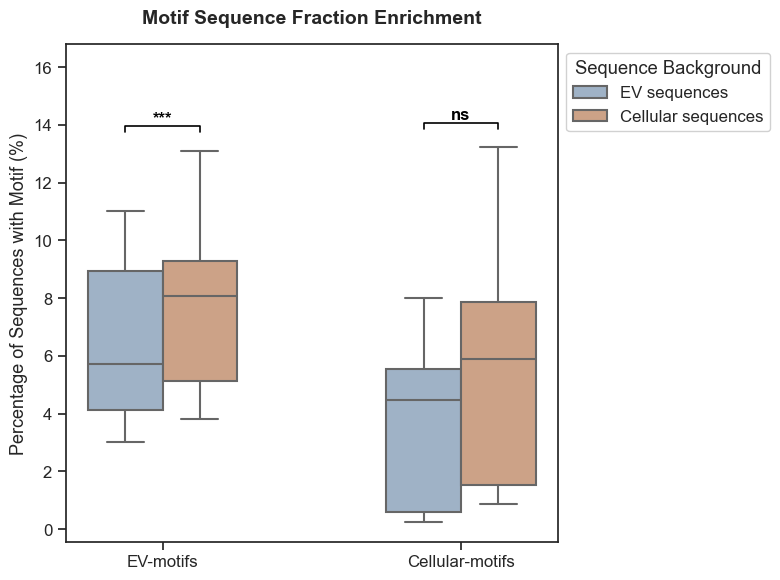

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 整理数据构建 DataFrame (将比例 * 100 转换为百分比展示更直观)
data = []

# 添加 EV-motifs 分组数据
for val in pair_ev_EVseq:
    data.append({'Sequence Fraction (%)': val * 100, 'Motif Type': 'EV-motifs', 'Sequence Background': 'EV sequences'})
for val in pair_ev_Cytoseq:
    data.append({'Sequence Fraction (%)': val * 100, 'Motif Type': 'EV-motifs', 'Sequence Background': 'Cellular sequences'})

# 添加 Cyto-motifs 分组数据
for val in pair_cyto_EVseq:
    data.append({'Sequence Fraction (%)': val * 100, 'Motif Type': 'Cellular-motifs', 'Sequence Background': 'EV sequences'})
for val in pair_cyto_Cytoseq:
    data.append({'Sequence Fraction (%)': val * 100, 'Motif Type': 'Cellular-motifs', 'Sequence Background': 'Cellular sequences'})

df_plot = pd.DataFrame(data)

# ================= 新增显著性符号转换函数 =================
def get_asterisks(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return 'ns'
# ==========================================================

# 2. 设置绘图参数
plt.figure(figsize=(8, 6))
sns.set_theme(style="ticks", font_scale=1.1)

# 配置更改后的指定颜色
palette = {'EV sequences': '#98B2CD', 'Cellular sequences': '#D89F7B'}

# 3. 绘制多组并列箱线图
ax = sns.boxplot(
    data=df_plot, 
    x='Motif Type', 
    y='Sequence Fraction (%)', 
    hue='Sequence Background',
    palette=palette,
    width=0.5,
    showfliers=True, 
    linewidth=1.5
)

# 4. 动态计算每组最大值以调整连线的 Y 轴位置
y_range = df_plot['Sequence Fraction (%)'].max() - df_plot['Sequence Fraction (%)'].min()
y_padding = y_range * 0.05  
h = y_range * 0.015  # 显著性折线下降的高度

max_ev = df_plot[df_plot['Motif Type'] == 'EV-motifs']['Sequence Fraction (%)'].max()
max_cyto = df_plot[df_plot['Motif Type'] == 'Cellular-motifs']['Sequence Fraction (%)'].max()

# ================= 绘制显著性连线和星号 =================
# EV-motifs 组 (x = 0, hue 箱体偏移大约是 ±0.125)
x1_ev, x2_ev = 0 - 0.125, 0 + 0.125
y_ev = max_ev + y_padding
ax.plot([x1_ev, x1_ev, x2_ev, x2_ev], [y_ev, y_ev+h, y_ev+h, y_ev], lw=1.2, color='black')
ax.text((x1_ev+x2_ev)/2, y_ev+h, get_asterisks(pval_ev), ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')

# Cyto-motifs 组 (x = 1)
x1_cyto, x2_cyto = 1 - 0.125, 1 + 0.125
y_cyto = max_cyto + y_padding
ax.plot([x1_cyto, x1_cyto, x2_cyto, x2_cyto], [y_cyto, y_cyto+h, y_cyto+h, y_cyto], lw=1.2, color='black')
ax.text((x1_cyto+x2_cyto)/2, y_cyto+h, get_asterisks(pval_cyto), ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')
# ==========================================================

# 动态扩展 Y 轴上限，防止文本和连线被裁剪
current_ymin, current_ymax = ax.get_ylim()
ax.set_ylim(current_ymin, max(current_ymax, max(y_ev, y_cyto) + y_padding * 4.5))

# 5. 图标美化与收尾
plt.title('Motif Sequence Fraction Enrichment', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Percentage of Sequences with Motif (%)', fontsize=13)
plt.xlabel('')

# 整理图例位置
plt.legend(title='Sequence Background', loc=0, bbox_to_anchor=(1, 1), framealpha=0.9)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from Bio import SeqIO

def get_sequence_level_densities(fimo_tsv, fasta_file):
    """统计每条特定序列中所有目标 Motif 的总命中密度 (hits/kb)"""
    # 1. 获取所有序列的 ID 和长度(Kb)
    seq_lengths = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        seq_lengths[record.id] = len(record.seq) / 1000.0
        
    # 2. 加载 FIMO 结果
    df = pd.read_csv(fimo_tsv, sep='\t', skipfooter=3, engine='python')
    
    # 3. 统计这条序列中所有 Motif 出现的【总次数】
    hits_per_seq = df.groupby('sequence_name').size()
    
    # 4. 计算每条序列的 Motif 频率 (Hits / Kb)
    # 注意：必须遍历由 fasta 提取的 seq_lengths 字典，确保 0 hit 的序列也参与计算
    seq_densities = []
    for seq_id, length_kb in seq_lengths.items():
        hits = hits_per_seq.get(seq_id, 0)
        seq_densities.append(hits / length_kb)
        
    return seq_densities

# ==========================================
# 1. 检验 EV-motifs 在 EV 序列中是否更富集
# ==========================================
# 获取含有 EV-motifs 的两组序列密度全集
ev_seq_densities_EV_motifs = get_sequence_level_densities(
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/enrichment/fimo_EV_motif_on_EV_seq/fimo.tsv", 
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/circRNA_ligated/EV_sequences.fasta"
)
cyto_seq_densities_EV_motifs = get_sequence_level_densities(
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/enrichment/fimo_EV_motif_on_Cyto_seq/fimo.tsv", 
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/circRNA_ligated/Cyto_sequences.fasta"
)

# 独立样本 Mann-Whitney U 检验
stat_ev, pval_ev = mannwhitneyu(ev_seq_densities_EV_motifs, cyto_seq_densities_EV_motifs, alternative='greater')

print("=== EV Motifs 富集分析 (序列维度 Motif 频率) ===")
print(f"EV 序列数量: {len(ev_seq_densities_EV_motifs)}, 平均频率: {np.mean(ev_seq_densities_EV_motifs):.4f} hits/kb")
print(f"Cyto序列数量: {len(cyto_seq_densities_EV_motifs)}, 平均频率: {np.mean(cyto_seq_densities_EV_motifs):.4f} hits/kb")
print(f"Mann-Whitney U 检验 P-value: {pval_ev:.4e}\n")


# ==========================================
# 2. 检验 Cyto-motifs 在 Cyto 序列中是否更富集
# ==========================================
# 获取含有 Cyto-motifs 的两组序列密度全集
cyto_seq_densities_Cyto_motifs = get_sequence_level_densities(
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/enrichment/fimo_Cyto_motif_on_Cyto_seq/fimo.tsv", 
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/circRNA_ligated/Cyto_sequences.fasta"
)
ev_seq_densities_Cyto_motifs = get_sequence_level_densities(
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/enrichment/fimo_Cyto_motif_on_EV_seq/fimo.tsv", 
    "/lulabdata3/huangkeyun/zhangys/RNA_locator/motif_analysis/circRNA_ligated/EV_sequences.fasta"
)

# 独立样本 Mann-Whitney U 检验
stat_cyto, pval_cyto = mannwhitneyu(cyto_seq_densities_Cyto_motifs, ev_seq_densities_Cyto_motifs, alternative='greater')

print("=== Cyto Motifs 富集分析 (序列维度 Motif 频率) ===")
print(f"Cyto序列数量: {len(cyto_seq_densities_Cyto_motifs)}, 平均频率: {np.mean(cyto_seq_densities_Cyto_motifs):.4f} hits/kb")
print(f"EV 序列数量: {len(ev_seq_densities_Cyto_motifs)}, 平均频率: {np.mean(ev_seq_densities_Cyto_motifs):.4f} hits/kb")
print(f"Mann-Whitney U 检验 P-value: {pval_cyto:.4e}")

=== EV Motifs 富集分析 (序列维度 Motif 频率) ===
EV 序列数量: 668, 平均频率: 2.7963 hits/kb
Cyto序列数量: 809, 平均频率: 1.2849 hits/kb
Mann-Whitney U 检验 P-value: 3.9158e-05

=== Cyto Motifs 富集分析 (序列维度 Motif 频率) ===
Cyto序列数量: 809, 平均频率: 1.5066 hits/kb
EV 序列数量: 668, 平均频率: 2.5073 hits/kb
Mann-Whitney U 检验 P-value: 9.5717e-01


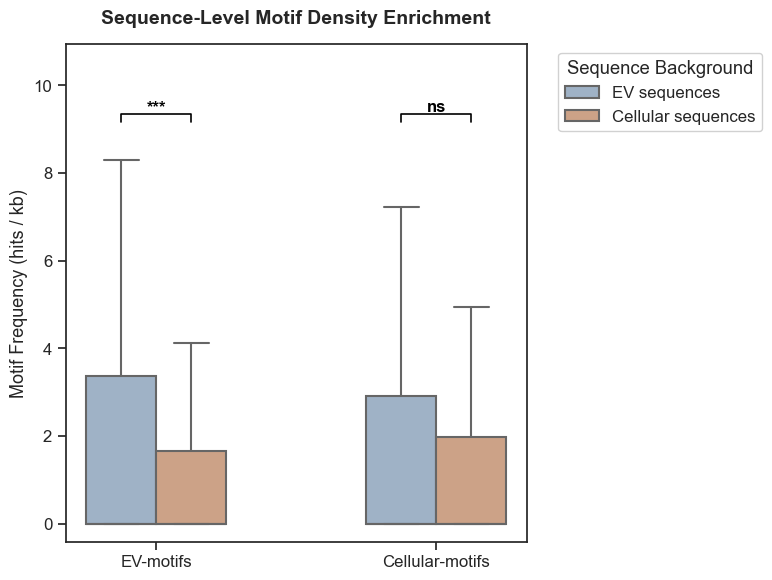

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 整理数据构建 DataFrame
data = []

# 添加 EV-motifs 分组数据
for val in ev_seq_densities_EV_motifs:
    data.append({'Density (hits/kb)': val, 'Motif Type': 'EV-motifs', 'Sequence Background': 'EV sequences'})
for val in cyto_seq_densities_EV_motifs:
    data.append({'Density (hits/kb)': val, 'Motif Type': 'EV-motifs', 'Sequence Background': 'Cellular sequences'})

# 添加 Cyto-motifs 分组数据
for val in ev_seq_densities_Cyto_motifs:
    data.append({'Density (hits/kb)': val, 'Motif Type': 'Cellular-motifs', 'Sequence Background': 'EV sequences'})
for val in cyto_seq_densities_Cyto_motifs:
    data.append({'Density (hits/kb)': val, 'Motif Type': 'Cellular-motifs', 'Sequence Background': 'Cellular sequences'})

df_plot = pd.DataFrame(data)

# ================= 新增显著性符号转换函数 =================
def get_asterisks(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return 'ns'
# ==========================================================

# 2. 设置绘图参数
plt.figure(figsize=(8, 6))
sns.set_theme(style="ticks", font_scale=1.1)
# 配置更改后的指定颜色
palette = {'EV sequences': '#98B2CD', 'Cellular sequences': '#D89F7B'}

# 3. 绘制多组并列箱线图
ax = sns.boxplot(
    data=df_plot, 
    x='Motif Type', 
    y='Density (hits/kb)', 
    hue='Sequence Background',
    palette=palette,
    width=0.5,
    showfliers=False, # 设为False可以隐藏长尾的极端异常点，使箱体对比更明显；若想看全貌可改为True
    linewidth=1.5
)

# 4. 动态计算 Y 轴用于添加折线和星号，避免遮挡
# 因为 showfliers=False，我们使用当前可见坐标轴的最大值作为标注基准高度
current_ymin, current_ymax = ax.get_ylim()
y_range = current_ymax - current_ymin
y_padding = y_range * 0.05
h = y_range * 0.02  # 显著性折线下降的高度

y_bracket = current_ymax + y_padding

# ================= 绘制显著性连线和星号 =================
# EV-motifs 组 (x = 0, hue 箱体偏移大约是 ±0.125)
x1_ev, x2_ev = 0 - 0.125, 0 + 0.125
ax.plot([x1_ev, x1_ev, x2_ev, x2_ev], [y_bracket, y_bracket+h, y_bracket+h, y_bracket], lw=1.2, color='black')
ax.text((x1_ev+x2_ev)/2, y_bracket+h, get_asterisks(pval_ev), ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')

# Cyto-motifs 组 (x = 1)
x1_cyto, x2_cyto = 1 - 0.125, 1 + 0.125
ax.plot([x1_cyto, x1_cyto, x2_cyto, x2_cyto], [y_bracket, y_bracket+h, y_bracket+h, y_bracket], lw=1.2, color='black')
ax.text((x1_cyto+x2_cyto)/2, y_bracket+h, get_asterisks(pval_cyto), ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')
# ==========================================================

# 动态扩展 Y 轴上限，防止文本被裁剪
ax.set_ylim(current_ymin, y_bracket + h + y_padding * 3.5)

# 5. 图标美化与收尾
plt.title('Sequence-Level Motif Density Enrichment', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Motif Frequency (hits / kb)', fontsize=13)
plt.xlabel('')

# 整理图例位置：bbox_to_anchor设为(1.05, 1)，loc='upper left' 可以将图例移到绘图区外侧右上方
plt.legend(title='Sequence Background', bbox_to_anchor=(1.05, 1), loc='upper left', framealpha=0.9)

# sns.despine(trim=True) # 移除顶部和右侧的边框轴线

plt.tight_layout()
plt.show()